We do mismatches

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from typing import Optional, Type, Union
from scipy.interpolate import CubicSpline
import time
from tqdm import tqdm

#few imports
from few.trajectory.inspiral import EMRIInspiral #function to generate trajectories
from few.trajectory.ode.base import ODEBase #superclass for defining modified flux trajectories
from few.trajectory.ode.flux import KerrEccEqFlux #Adiabatic KerrEccEq base trajectory class

from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum
from few.utils.modeselector import ModeSelector
from few.utils.exceptions import TrajectoryOffGridException

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform,
)

##### SuperKludge Imports #####
from few.trajectory.ode.flux import SuperKludgeFlux, KerrEccEqFlux #trajectory module. KerrEccEqFlux used to generate p_at_plunge
from few.waveform.waveform import SuperKludgeWaveform #waveform module
###############################

from few.waveform.base import SphericalHarmonicWaveformBase #generic waveform generation class
from few.utils.baseclasses import SphericalHarmonic, KerrEccentricEquatorial, ParallelModuleBase, BackendLike

from few.utils.constants import YRSID_SI

from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )

use_gpu = False #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself.

In [2]:
# define parameters
m1 = 1e6
m2 = 1e1
e0 = 0.1 #must be >> 0.0, but << 1.0 :)
Y0 = 1.0
dist = 1.0
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
Phi_phi0 = 0.1
Phi_theta0 = 0.2
Phi_r0 = 0.3
dt = 10.0
T = 2.0
chi2 = 0.5

#initializing trajectories
start = time.time()
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
print(time.time() - start)

adiabatic_traj = EMRIInspiral(func=KerrEccEqFlux)

#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
p0 = 9.0
#p0 = get_p_at_t(traj_module=adiabatic_traj, t_out=T, traj_args=[m1, m2, a, e0, Y0]) + 1.0 #near plunge EMRI
print('p0: ', p0)

7.394684076309204
p0:  9.0


In [3]:
#waveform setup

sum_kwargs=dict(pad_output=False, odd_len=True)

start = time.time()
waveform_model = GenerateEMRIWaveform(SuperKludgeWaveform,sum_kwargs=sum_kwargs, return_list=True)
print(time.time()-start)

evolve_1PA = True
evolve_primary = False
evolve_2PA = True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
add_args_null = [0.0, evolve_1PA, evolve_primary, evolve_2PA]


65.09995985031128


In [5]:
#mismatch analysis for varying a

a_range = np.linspace(0.0,0.95,6)

mismatches_plus = []
mismatches_cross = []

for i in tqdm(range(len(a_range))):
    a = a_range[i]
    
    wave_null = waveform_model(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args_null, dt=dt, T=T)
    wave_null_plus, wave_null_cross = wave_null
    
    wave_chi2 = waveform_model(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
    wave_chi2_plus, wave_chi2_cross = wave_chi2
        
    if len(wave_null_plus) < len(wave_chi2_plus):
        wave_chi2_plus = wave_chi2_plus[:len(wave_null_plus)]
    elif len(wave_null_plus) > len(wave_chi2_plus):
        wave_null_plus = wave_null_plus[:len(wave_chi2_plus)]

    if len(wave_null_cross) < len(wave_chi2_cross):
        wave_chi2_cross = wave_chi2_cross[:len(wave_null_cross)]
    elif len(wave_null_cross) > len(wave_chi2_cross):
        wave_null_cross = wave_null_cross[:len(wave_chi2_cross)]
        
    mismatches_plus.append(get_mismatch(wave_null_plus, wave_chi2_plus))
    mismatches_cross.append(get_mismatch(wave_null_cross, wave_chi2_cross))

np.savetxt("mismatches_plus_chi2_varying_a.txt",mismatches_plus)
np.savetxt("mismatches_cross_chi2_varying_a.txt",mismatches_cross)


100%|█████████████████████████████████████████████| 6/6 [03:38<00:00, 36.44s/it]


In [8]:
#mismatch analysis for varying e0

e0_range = np.linspace(0.1,0.5,6)
a = 0.9

mismatches_plus = []
mismatches_cross = []

for i in tqdm(range(len(e0_range))):
    e0 = e0_range[i]
    
    wave_null = waveform_model(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args_null, dt=dt, T=T)
    wave_null_plus, wave_null_cross = wave_null
    
    wave_chi2 = waveform_model(m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
    wave_chi2_plus, wave_chi2_cross = wave_chi2
        
    if len(wave_null_plus) < len(wave_chi2_plus):
        wave_chi2_plus = wave_chi2_plus[:len(wave_null_plus)]
    elif len(wave_null_plus) > len(wave_chi2_plus):
        wave_null_plus = wave_null_plus[:len(wave_chi2_plus)]

    if len(wave_null_cross) < len(wave_chi2_cross):
        wave_chi2_cross = wave_chi2_cross[:len(wave_null_cross)]
    elif len(wave_null_cross) > len(wave_chi2_cross):
        wave_null_cross = wave_null_cross[:len(wave_chi2_cross)]
        
    mismatches_plus.append(get_mismatch(wave_null_plus, wave_chi2_plus))
    mismatches_cross.append(get_mismatch(wave_null_cross, wave_chi2_cross))

np.savetxt("mismatches_plus_chi2_varying_e0.txt",mismatches_plus)
np.savetxt("mismatches_cross_chi2_varying_e0.txt",mismatches_cross)


100%|█████████████████████████████████████████████| 6/6 [04:46<00:00, 47.76s/it]


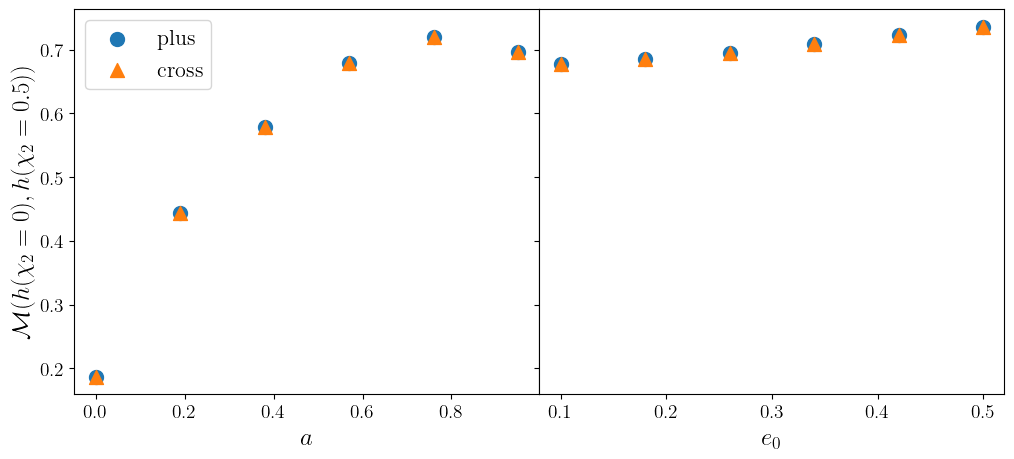

In [24]:
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

label_fontsize = 18
tick_fontsize = 14
title_fontsize = 16

mismatches_plus_a = np.loadtxt("mismatches_plus_chi2_varying_a.txt")
mismatches_cross_a = np.loadtxt("mismatches_cross_chi2_varying_a.txt")

mismatches_plus_e0 = np.loadtxt("mismatches_plus_chi2_varying_e0.txt")
mismatches_cross_e0 = np.loadtxt("mismatches_cross_chi2_varying_e0.txt")

fig, axs = plt.subplots(1,2, figsize=(12,5), sharey=True)

axs[0].scatter(a_range, mismatches_plus_a,s=100,label='plus')
axs[0].scatter(a_range, mismatches_cross_a,marker='^',s=100,label='cross')
axs[0].set_xlabel(r'$a$', fontsize=label_fontsize)
axs[0].set_ylabel(r'$\mathcal{M}(h(\chi_2 = 0), h(\chi_2 = 0.5))$', fontsize=label_fontsize)
axs[0].tick_params(axis='both', which='major', labelsize=tick_fontsize)
axs[0].legend(fontsize=16)

axs[1].scatter(e0_range, mismatches_plus_e0,s=100)
axs[1].scatter(e0_range, mismatches_cross_e0,marker='^',s=100)
axs[1].set_xlabel(r'$e_0$', fontsize=label_fontsize)
axs[1].tick_params(axis='both', which='major', labelsize=tick_fontsize)

plt.subplots_adjust(wspace = 0)
plt.savefig("mismatch_sanity.png",dpi=300,bbox_inches=;
plt.show()

Text(0.5, 0, '$a$')

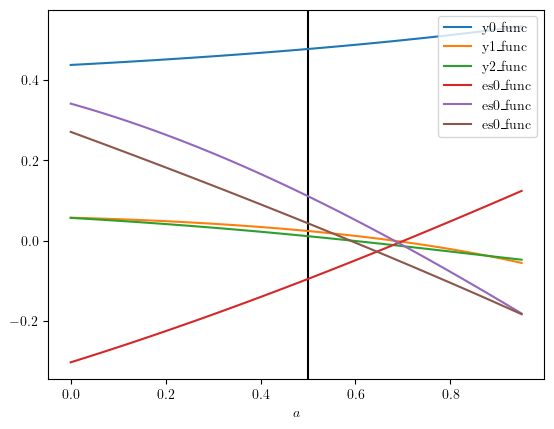

In [23]:
from few.trajectory.ode.SuperKludge02_support import y0_func, y1_func, y2_func, es0_func, es1_func, es2_func
import numpy as np
import matplotlib.pyplot as plt

yPhi = 0.5 #whatever
Lambda = 0.5 #whatever

Chi2 = 0.5
Chi1_range = np.linspace(0.0,0.95,100)

plt.axvline(Chi2,color='k')
plt.plot(Chi1_range, y0_func(yPhi, Lambda, Chi1_range), label='y0_func')
plt.plot(Chi1_range, y1_func(yPhi, Lambda, Chi1_range, Chi2), label='y1_func')
plt.plot(Chi1_range, y2_func(yPhi, Lambda, Chi1_range, Chi2), label='y2_func')
plt.plot(Chi1_range, es0_func(yPhi, Lambda, Chi1_range), label='es0_func')
plt.plot(Chi1_range, es1_func(yPhi, Lambda, Chi1_range, Chi2), label='es0_func')
plt.plot(Chi1_range, es2_func(yPhi, Lambda, Chi1_range, Chi2), label='es0_func')
plt.legend()
plt.xlabel(r'$a$')